# Step 1: Install Requirements

In [ ]:
# clone YOLOv5 repo
!git clone https://github.com/ultralytics/yolov5

Cloning into 'yolov5'...


In [ ]:
# install dependencies if you do not have a pytorch environment
# %pip install -qr requirements.txt

import torch
import os
from IPython.display import Image, clear_output  # to display images

print(f"Setup complete. Using torch {torch.__version__} ({torch.cuda.get_device_properties(0).name if torch.cuda.is_available() else 'CPU'})") # check the gpu

Setup complete. Using torch 1.12.0 (NVIDIA GeForce RTX 2070 Super)


In [ ]:
cd yolov5

D:\GitHub\furseal\yolov5


# Step 3: Train a custom face detection model based on YOLOv5 model

Here, we are able to pass a number of arguments:
- **img:** define input image size
- **batch:** determine batch size
- **epochs:** define the number of training epochs. (Note: often, 3000+ are common here!)
- **data:** Our dataset locaiton is saved in the `./datasets`
- **weights:** specify a path to weights to start transfer learning from. Here we choose the generic COCO pretrained checkpoint (the tiny version: yolov5s).
- **cache:** cache images for faster training

In [ ]:
!python train.py --img 416 --batch 16 --epochs 150 --data ../datasets/data.yaml --weights yolov5s.pt --cache

train: weights=yolov5s.pt, cfg=, data=../datasets/data.yaml, hyp=data\hyps\hyp.scratch-low.yaml, epochs=150, batch_size=16, imgsz=416, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, bucket=, cache=ram, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=runs\train, name=exp, exist_ok=False, quad=False, cos_lr=False, label_smoothing=0.0, patience=100, freeze=[0], save_period=-1, seed=0, local_rank=-1, entity=None, upload_dataset=False, bbox_interval=-1, artifact_alias=latest
github: up to date with https://github.com/ultralytics/yolov5 
YOLOv5  v6.2-57-gf2b8f3f Python-3.9.12 torch-1.12.0 CUDA:0 (NVIDIA GeForce RTX 2070 Super, 8192MiB)

hyperparameters: lr0=0.01, lrf=0.01, momentum=0.937, weight_decay=0.0005, warmup_epochs=3.0, warmup_momentum=0.8, warmup_bias_lr=0.1, box=0.05, cls=0.5, cls_pw=1.0, obj=1.0, obj_pw=1.0, iou_t=0.2, anchor_t=4.0, fl_gamma=0.0, hsv_h=0.015, h

# Evaluate Custom YOLOv5 Detector Performance
Training losses and performance metrics are saved to Tensorboard and also to a logfile.

If you are new to these metrics, the one you want to focus on is `mAP_0.5`

In [ ]:
# Start tensorboard
# Launch after you have started training
# logs save in the folder "runs"
%load_ext tensorboard
%tensorboard --logdir runs

#Run Inference  With Trained Weights
Run inference with a pretrained checkpoint on contents of `test/images` folder

In [ ]:
!python detect.py --weights runs/train/exp/weights/best.pt --img 416 --conf 0.1 --source ../datasets/test/images --save-crop

detect: weights=['runs/train/exp/weights/best.pt'], source=../datasets/test/images, data=data\coco128.yaml, imgsz=[416, 416], conf_thres=0.1, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=True, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs\detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False
YOLOv5  v6.2-57-gf2b8f3f Python-3.9.12 torch-1.12.0 CUDA:0 (NVIDIA GeForce RTX 2070 Super, 8192MiB)

Fusing layers... 
Model summary: 213 layers, 7012822 parameters, 0 gradients, 15.8 GFLOPs
image 1/4 D:\GitHub\furseal\datasets\test\images\7T5A6512_JPG.rf.4f6efcbaf8ac7e03321e5fe3d2997343.jpg: 416x416 1 face, 18.0ms
image 2/4 D:\GitHub\furseal\datasets\test\images\7T5A6714_JPG.rf.e86aeb8b17e953af980758bb1f84b022.jpg: 416x416 (no detections), 16.9ms
image 3/4 D:\GitHub\furseal\datasets\test\images\7T5A8563_JPG.rf.3d247a6bf3ab7b04772c

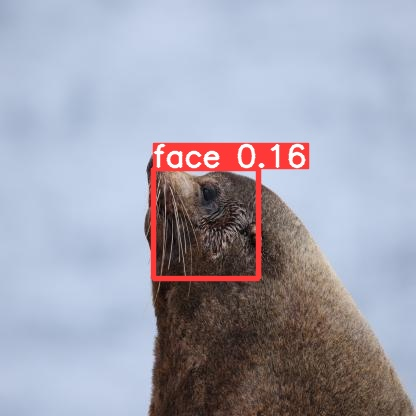

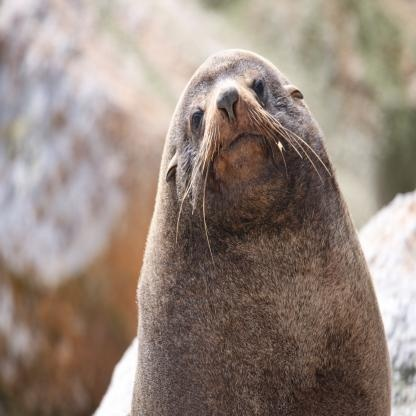

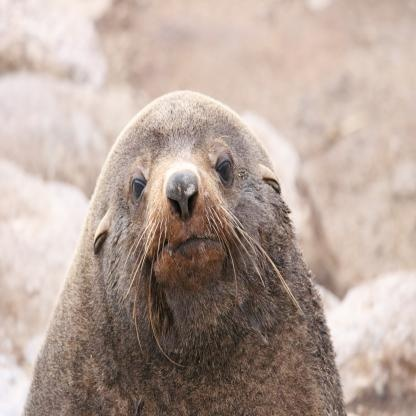

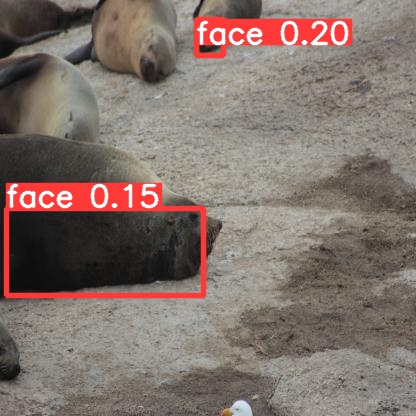

In [ ]:
#display inference on ALL test images

import glob
from IPython.display import Image, display

for imageName in glob.glob('runs/detect/exp/*.jpg'): #assuming JPG
    display(Image(filename=imageName))
    print("\n")